# Distance Mapの実装

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy

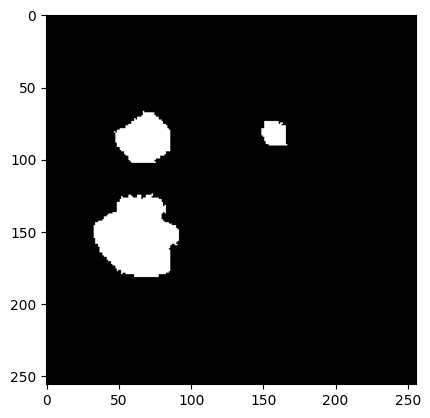

In [55]:
mask = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
mask = cv2.resize(mask, (256, 256))
mask = np.where(mask > 0, 1, 0)
plt.imshow(mask, cmap='gray')

# Original Distance Map O-DM
D(x) = min d(x, b)

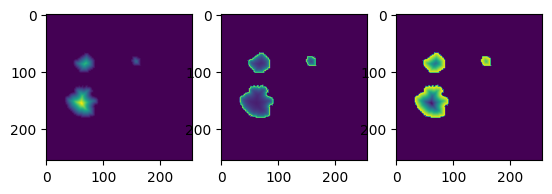

In [ ]:
odm = scipy.ndimage.distance_transform_edt(mask)
idm = 1/(odm + 1)
idm[mask == 0] = 0

nidm = (np.max(odm) + 1 - odm)/np.max(odm)
nidm[mask==0] = 0

plt.subplot(131)
plt.imshow(odm)   
plt.subplot(132)
plt.imshow(idm)
plt.subplot(133)    
plt.imshow(nidm)
plt.show()

In [75]:
import torch
import torch.nn.functional as F
import distmap as dm

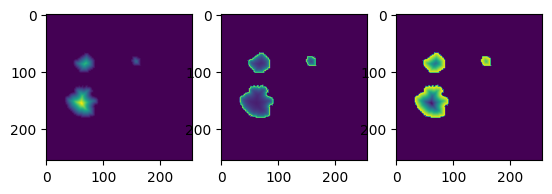

In [81]:
mask_tensor = torch.tensor(mask).unsqueeze(0).unsqueeze(0).float() 
odm_tensor = dm.euclidean_distance_transform(mask_tensor)
idm_tensor = 1/(odm_tensor + 1)
idm_tensor[mask_tensor == 0] = 0

nidm_tensor = (torch.max(odm_tensor) + 1 - odm_tensor)/torch.max(odm_tensor)
nidm_tensor[mask_tensor==0] = 0

plt.subplot(131)
plt.imshow(odm_tensor[0,0])   
plt.subplot(132)
plt.imshow(idm_tensor[0,0])
plt.subplot(133)    
plt.imshow(nidm_tensor[0,0])
plt.show()